In [1]:
#解决中文乱码问题
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']   # macOS 自带的中文字体
plt.rcParams['axes.unicode_minus'] = False               # 修复负号显示成方块


In [2]:
# 读取清洗后的数据
df = pd.read_csv('../data/processed/UserBehavior_clean.csv', dtype={'user_id': str, 'item_id': str, 'category_id': str})
df['datetime'] = pd.to_datetime(df['datetime'])
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour

print('总行为数：', len(df))
print('用户数：', df['user_id'].nunique())
print('人均行为数：', round(len(df) / df['user_id'].nunique(), 1))


总行为数： 999531
用户数： 9739
人均行为数： 102.6


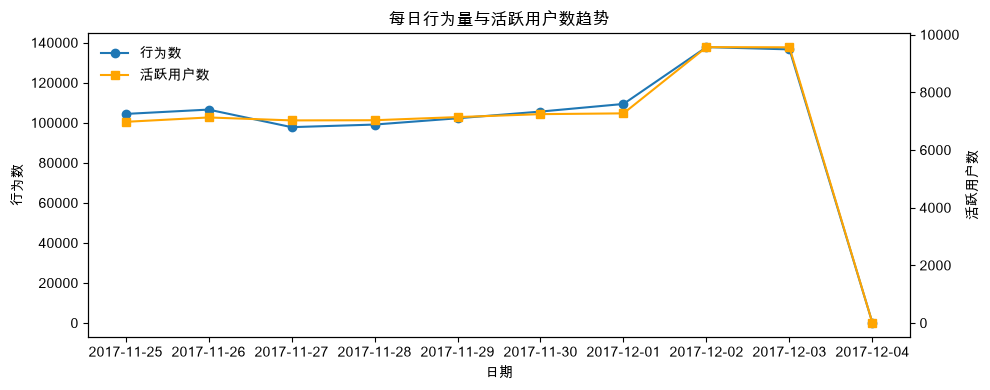

In [3]:
# 按天统计行为数和活跃用户数
daily = df.groupby('date').agg(行为数=('user_id', 'size'), 活跃用户数=('user_id', 'nunique'))

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(daily.index, daily['行为数'], marker='o', label='行为数')
ax1.set_ylabel('行为数')
ax1.set_xlabel('日期')
ax1.set_title('每日行为量与活跃用户数趋势')
ax2 = ax1.twinx()
ax2.plot(daily.index, daily['活跃用户数'], marker='s', color='orange', label='活跃用户数')
ax2.set_ylabel('活跃用户数')
plt.xticks(rotation=45)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=False)

plt.tight_layout()
plt.savefig('../output/charts/日趋势.png', dpi=150)
plt.show()


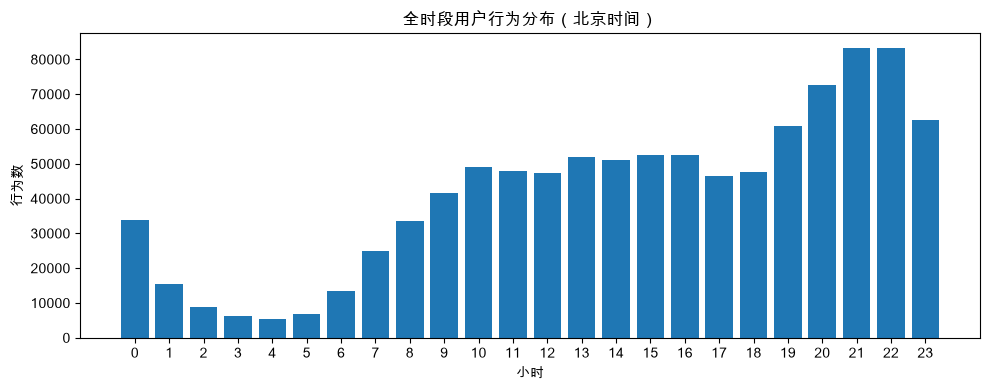

In [4]:
# 小时活跃分布
hourly = df.groupby('hour').size()

plt.figure(figsize=(10, 4))
plt.bar(hourly.index, hourly.values)
plt.xlabel('小时'); plt.ylabel('行为数')
plt.title('全时段用户行为分布（北京时间）')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('../output/charts/小时分布.png', dpi=150)
plt.show()


In [5]:
# 用户行为漏斗分析
pv_users = df[df['behavior_type'] == 'pv']['user_id'].nunique()
cart_users = df[df['behavior_type'] == 'cart']['user_id'].nunique()
buy_users = df[df['behavior_type'] == 'buy']['user_id'].nunique()

print('浏览用户：', pv_users)
print('加购用户：', cart_users, f'（占浏览 {cart_users/pv_users:.1%}）')
print('购买用户：', buy_users, f'（占浏览 {buy_users/pv_users:.1%}）')


浏览用户： 9706
加购用户： 7323 （占浏览 75.4%）
购买用户： 6689 （占浏览 68.9%）
